# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


In [19]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [4]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [5]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [6]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [17]:
# 1 num atributos y significado:

atributos = diabetes.feature_names
significados = {"age": "edad",
    "sex": "sexo",
    "bmi": "índice de masa corporal",
    "bp": "presión arterial media",
    "s1": "colesterol total",
    "s2": "LDL",
    "s3": "HDL",
    "s4": "ratio colesterol",
    "s5": "niveles de triglicéridos",
    "s6": "glucosa en sangre"}

print(len(atributos)) # num atributos

for a in atributos: # significados atributos
    print(f"{a}: {significados[a]}")

10
age: edad
sex: sexo
bmi: índice de masa corporal
bp: presión arterial media
s1: colesterol total
s2: LDL
s3: HDL
s4: ratio colesterol
s5: niveles de triglicéridos
s6: glucosa en sangre


In [13]:
# 2 rel entre data y target:

print(" - data = variables predictoras (X), forma:", diabetes.data.shape)
print(" - target = variable objetivo (y), forma:", diabetes.target.shape)
print(" - y representa la progresión de la diabetes un año después")

 - data = variables predictoras (X), forma: (442, 10)
 - target = variable objetivo (y), forma: (442,)
 - y representa la progresión de la diabetes un año después


In [14]:
# 3 num registros
print(diabetes.data.shape[0]) # num registros
print("Número de variables predictoras:", diabetes.data.shape[1])
print("Número de variables objetivo: 1")


442
Número de variables predictoras: 10
Número de variables objetivo: 1


#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [15]:
diabetes['data'].shape

(442, 10)

In [16]:
diabetes['target'].shape

(442,)

## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [21]:
from sklearn.linear_model import LinearRegression

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [36]:
diabetes_model = LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [23]:
# train, primeros 422 registros

diabetes_data_train = diabetes.data[:-20]
diabetes_target_train = diabetes.target[:-20]

# test, últimos 20
diabetes_data_test = diabetes.data[-20:]
diabetes_target_test = diabetes.target[-20:]


In [ ]:
# VERIFICO LAS FORMAS


Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [24]:
# crep df
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target


In [ ]:
# análisis exploratorio:

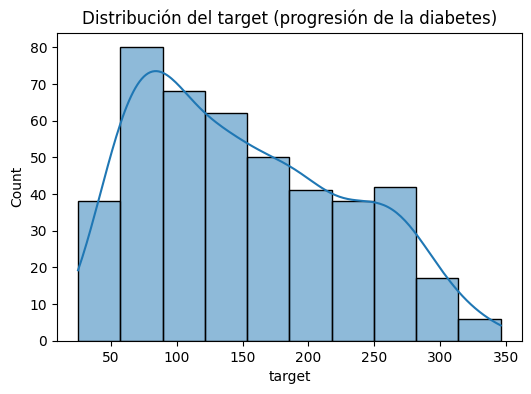

In [25]:

# distribución del target
plt.figure(figsize=(6,4))
sns.histplot(df["target"], kde=True)
plt.title("Distribución del target (progresión de la diabetes)")
plt.show()


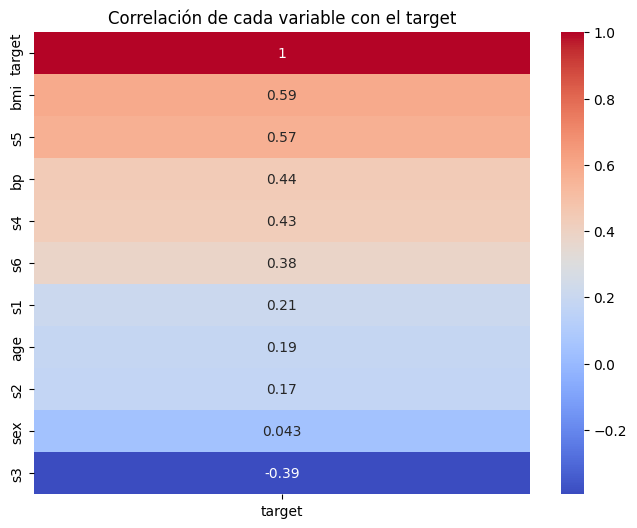

In [26]:
# correlaciones con el target
plt.figure(figsize=(8,6))
sns.heatmap(df.corr()[["target"]].sort_values(by="target", ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlación de cada variable con el target")
plt.show()


In [28]:
# entreanr modelo

diabetes_model.fit(diabetes_data_train, diabetes_target_train)

# impromo intercepto y coef
print(diabetes_model.intercept_) # itnercepto
print(diabetes_model.coef_) # coef

# muestro coef con nomb de variables
coef_df = pd.DataFrame({"feature": diabetes.feature_names,
    "coeficiente": diabetes_model.coef_})


print(coef_df) # coef por variable

152.76429169049118
[ 3.06094248e-01 -2.37635570e+02  5.10538048e+02  3.27729878e+02
 -8.14111926e+02  4.92799595e+02  1.02841240e+02  1.84603496e+02
  7.43509388e+02  7.60966464e+01]
  feature  coeficiente
0     age     0.306094
1     sex  -237.635570
2     bmi   510.538048
3      bp   327.729878
4      s1  -814.111926
5      s2   492.799595
6      s3   102.841240
7      s4   184.603496
8      s5   743.509388
9      s6    76.096646


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [29]:
# predecir valores del test
predicciones_test = diabetes_model.predict(diabetes_data_test)

print(diabetes_target_test) # valores reales (y_test)

print(predicciones_test) # predicciones del modelo


[233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]


#### Print your `diabetes_target_test` and compare with the prediction. 

In [30]:
# imprimovalores reales y predicciones

print(diabetes_target_test) # valores reales (diabetes_target_test)

print(predicciones_test) # predicciones del modelo


[233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]


#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [32]:
# comparo valores reales vs predicciones
print(diabetes_target_test) # alores reales (y_test)

print(predicciones_test) # predicciones del modelo


[233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]


In [33]:
# iguales?
iguales = (diabetes_target_test == predicciones_test)
print(iguales.all())

False


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [34]:
from sklearn import preprocessing
from sklearn import metrics

In [35]:
# escalo los datos
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(diabetes.data)

# divido en train/test (últimos 20 como test)
X_train_scaled = X_scaled[:-20]
X_test_scaled = X_scaled[-20:]

y_train = diabetes.target[:-20]
y_test = diabetes.target[-20:]

# nuevo modelo
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

# predicciones
scaled_pred = scaled_model.predict(X_test_scaled)

# métricas
MAE_scaled = metrics.mean_absolute_error(y_test, scaled_pred)
MSE_scaled = metrics.mean_squared_error(y_test, scaled_pred)
RMSE_scaled = np.sqrt(MSE_scaled)

print("MAE:", MAE_scaled)
print("MSE:", MSE_scaled)
print("RMSE:", RMSE_scaled)


MAE: 36.60961865545879
MSE: 2004.51868633421
RMSE: 44.77185149549
